### Name: Aveel Maynard Lewis
### Class: AIML Roll no.: 36

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [15]:
def fetch_indicator(code, year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]
    data = {}
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data, name=code)

In [16]:
gdp = fetch_indicator("NY.GDP.MKTP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [45]:
df = pd.concat([gdp, pop, life, lit], axis=1)
df.columns = ['GDP', 'Population', 'LifeExpectency', 'Literacy']
df.dropna(inplace=True)

In [46]:
df.head()

,GDP,Population,LifeExpectency,Literacy
Africa Eastern and Southern,1.228968e+12,731821393,64.487020,73.055977
Africa Western and Central,1.063649e+12,497387180,57.987813,60.780979
Arab World,3.747417e+12,471352066,71.876096,78.271927
Central Europe and the Baltics,1.954419e+12,100071871,76.652299,99.479919
Early-demographic dividend,1.403469e+13,3470644834,71.430455,81.242798


In [47]:
df.tail()

,GDP,Population,LifeExpectency,Literacy
Uruguay,7.059411e+10,3390913,76.468,98.849998
Uzbekistan,9.009593e+10,34938955,72.147,100.000000
Viet Nam,4.134452e+11,99680655,74.502,96.129997
West Bank and Gaza,1.916550e+10,5043612,76.662,97.839996
Zambia,2.916378e+10,20152938,65.279,79.975143


In [48]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

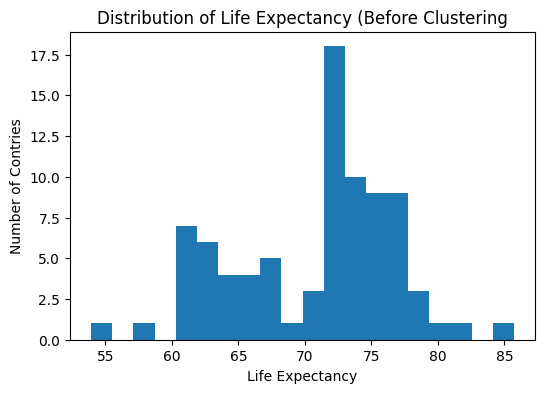

In [49]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectency"], bins = 20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Contries")
plt.title("Distribution of Life Expectancy (Before Clustering")
plt.show()

## Elbow Method

k	WCSS
1 	 336.0
2 	 213.8192086938365
3 	 111.64903546219871
4 	 94.3751436906698
5 	 65.95332852024687
6 	 54.87746144283372
7 	 49.0342394405038
8 	 33.29136731009751
9 	 26.456828946635316
10 	 24.5706126412196


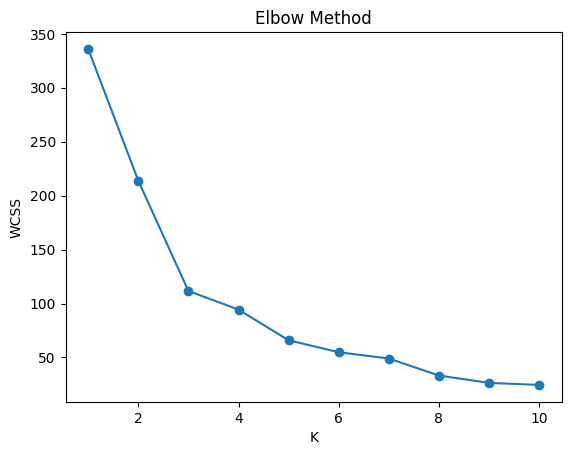

In [50]:
wcss = []
for k in range(1,11):
    km = KMeans(n_clusters = k, random_state = 0)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i+1, "\t", wcss[i])

plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Clustering Agorithm

AttributeError: module 'matplotlib.pyplot' has no attribute 'scater'

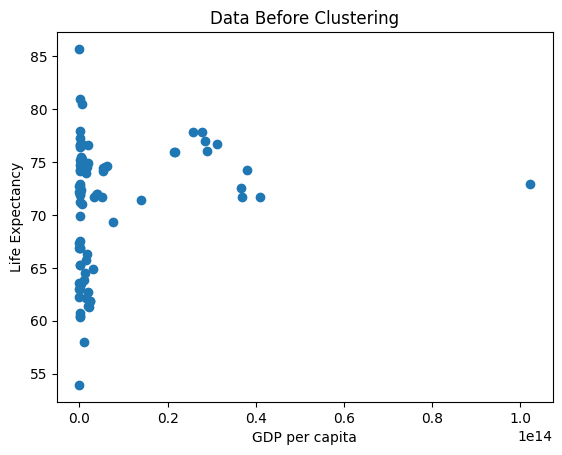

In [64]:
plt.scatter(df["GDP"], df["LifeExpectency"])
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
India = df.loc['India']
plt.scater(India["GDP"],India["LifeExpectancy"],s=400,color="red", marker = 'X')
plt.txt(India["GDP"],India["LifeExpectancy"], 'India')
plt.show()

In [52]:
kmeans = KMeans(n_clusters = 3, random_state = 0)
labels_km = kmeans.fit_predict(x_scaled)
df["KMeansCluster"] = labels_km

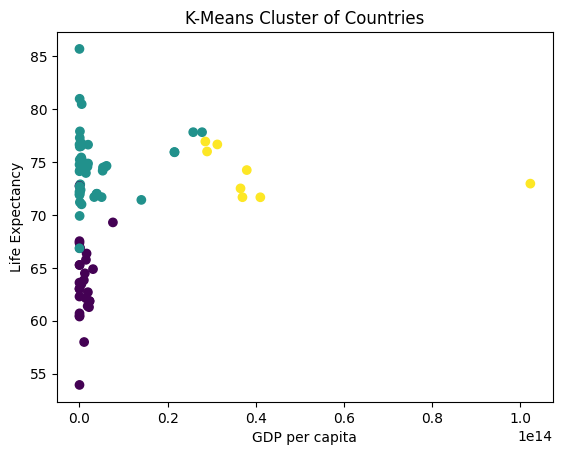

In [53]:
plt.scatter(df["GDP"], df["LifeExpectency"], c = labels_km)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Cluster of Countries")
plt.show()

In [54]:
hc = AgglomerativeClustering(n_clusters = 3)
labels_hc = hc.fit_predict(x_scaled)
df["HierarchicalCluster"] = labels_hc

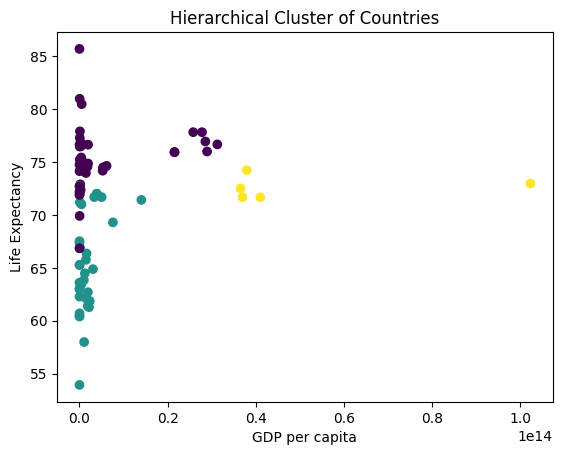

In [55]:
plt.scatter(df["GDP"], df["LifeExpectency"], c = labels_hc)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Cluster of Countries")
plt.show()

In [56]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectency", "Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectency   Literacy
KMeansCluster                                                       
0              1.029297e+12  5.736557e+08       63.679633  67.141161
1              3.520736e+12  4.009111e+08       74.568088  92.446706
2              4.293310e+13  4.937925e+09       74.092408  90.542451


In [57]:
country_name = "India"
result = df.loc[country_name]

print("Country: ", country_name)
print("GDP per capita: ", result["GDP"])
print("Population: ", result["Population"])
print("Life Expectancy: ", result["LifeExpectency"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country:  India
GDP per capita:  3346107287730.93
Population:  1425423212.0
Life Expectancy:  71.698
Literacy Rate:  76.3199996948242
KMeans Cluster:  1.0
Hierarchical Cluster:  1.0


In [58]:
country_name = "North America"
result = df.loc[country_name]

print("Country: ", country_name)
print("GDP per capita: ", result["GDP"])
print("Population: ", result["Population"])
print("Life Expectancy: ", result["LifeExpectency"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country:  North America
GDP per capita:  27803134368745.3
Population:  373018004.0
Life Expectancy:  77.8327679594239
Literacy Rate:  98.7891464233398
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0


In [59]:
country_name = "Brazil"
result = df.loc[country_name]

print("Country: ", country_name)
print("GDP per capita: ", result["GDP"])
print("Population: ", result["Population"])
print("Life Expectancy: ", result["LifeExpectency"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country:  Brazil
GDP per capita:  1951923832083.87
Population:  210306415.0
Life Expectancy:  74.872
Literacy Rate:  94.3853874531348
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0


In [60]:
country_name = "Viet Nam"
result = df.loc[country_name]

print("Country: ", country_name)
print("GDP per capita: ", result["GDP"])
print("Population: ", result["Population"])
print("Life Expectancy: ", result["LifeExpectency"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country:  Viet Nam
GDP per capita:  413445230668.578
Population:  99680655.0
Life Expectancy:  74.502
Literacy Rate:  96.129997253418
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0


In [61]:
country_name = "Bahrain"
result = df.loc[country_name]

print("Country: ", country_name)
print("GDP per capita: ", result["GDP"])
print("Population: ", result["Population"])
print("Life Expectancy: ", result["LifeExpectency"])
print("Literacy Rate: ", result["Literacy"])
print("KMeans Cluster: ", result["KMeansCluster"])
print("Hierarchical Cluster: ", result["HierarchicalCluster"])

Country:  Bahrain
GDP per capita:  46458191489.3617
Population:  1524693.0
Life Expectancy:  80.992
Literacy Rate:  97.870002746582
KMeans Cluster:  1.0
Hierarchical Cluster:  0.0
